In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Analysis Using Status Clean column/Datasets for analysis/waterpoint_dataset_without_population_dataset_integration (5) 2.csv')

In [ ]:
df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,management_clean,pay_clean,status_clean,subjective_quality_clean,facility_type,count,report_year,report_month,status_numeric,age_group
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,Community,Paid,Needs Maintenance,Unknown,Improved,1,2010,4,1,26-30
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,Community,Paid,Needs Maintenance,Unknown,Improved,1,2010,4,1,26-30
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,Community,Unknown,Needs Maintenance,Unknown,Improved,1,2010,4,1,26-30
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,Other,Unknown,Failed,Unknown,Improved,1,2010,4,0,26-30
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,Community,Unknown,Failed,Unknown,Improved,1,2010,4,0,21-25


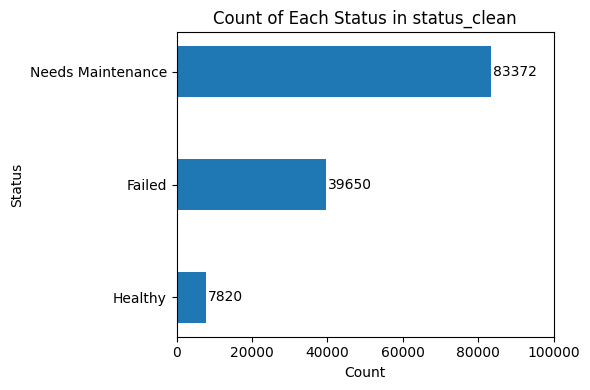

In [ ]:
import matplotlib.pyplot as plt

# Count values (sorted decreasing)
status_counts = df['status_clean'].value_counts()

plt.figure(figsize=(6,4))

bars = plt.barh(status_counts.index, status_counts.values, height=0.45)

# Largest on top
plt.gca().invert_yaxis()

plt.xlabel('Count')
plt.ylabel('Status')
plt.title('Count of Each Status in status_clean')

max_val = status_counts.max()

for bar in bars:
    width = bar.get_width()
    plt.text(width + max_val*0.005,             # small space after bar
             bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center',
             ha='left',
             fontsize=10)

# Extend axis slightly so text stays inside
plt.xlim(0, max_val * 1.2)

plt.tight_layout()
plt.show()

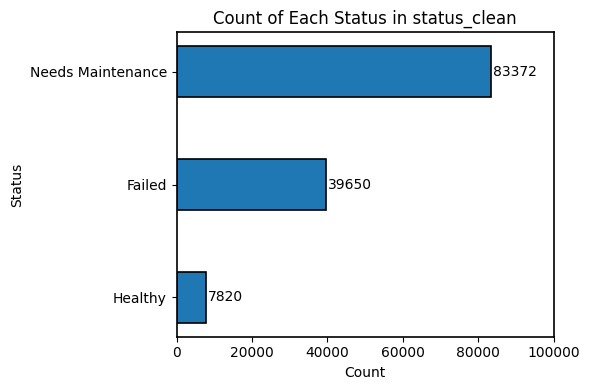

In [ ]:
import matplotlib.pyplot as plt

# Count values
status_counts = df['status_clean'].value_counts()

plt.figure(figsize=(6,4))

# Horizontal bars with black outline
bars = plt.barh(
    status_counts.index,
    status_counts.values,
    height=0.45,
    edgecolor='black',     # bar outline
    linewidth=1.2
)

# Largest on top
plt.gca().invert_yaxis()

plt.xlabel('Count')
plt.ylabel('Status')
plt.title('Count of Each Status in status_clean')

max_val = status_counts.max()

# Add values after bar ends
for bar in bars:
    width = bar.get_width()
    plt.text(width + max_val*0.005,
             bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center',
             ha='left',
             fontsize=10,)

# Keep everything inside
plt.xlim(0, max_val * 1.2)

# Make the axis box black
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

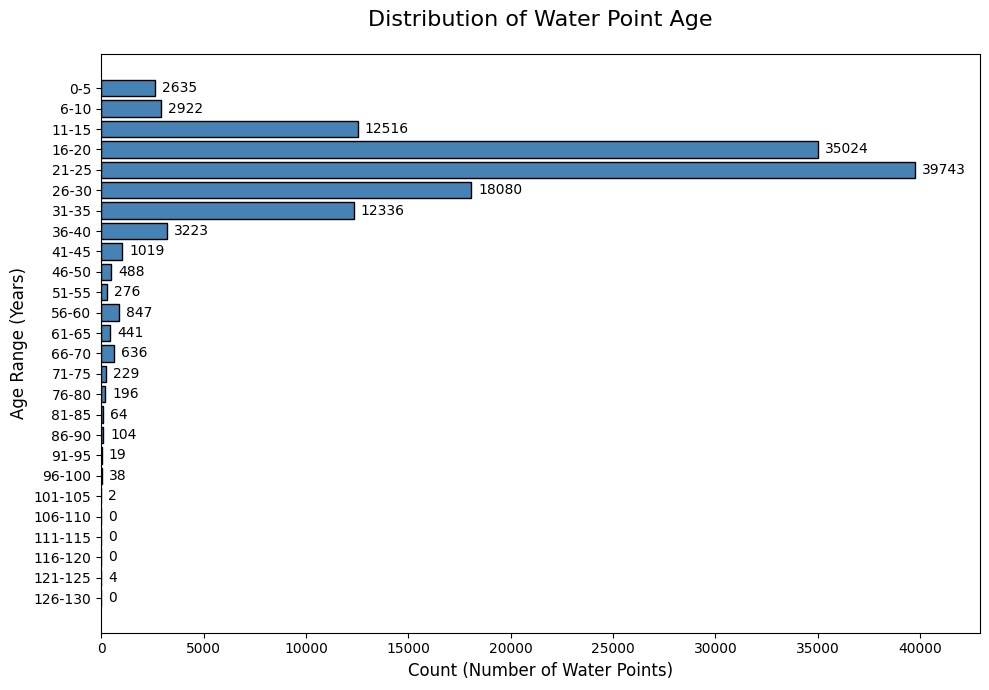

In [ ]:
# 1. Define bin edges and labels (0-5, 6-10, 11-15, etc.)
max_age = int(df["Water_Point_Age"].max())
edges = [-1] + list(range(5, max_age + 10, 5))
labels = [f"{edges[i]+1}-{edges[i+1]}" for i in range(len(edges)-1)]

# 2. Categorize the data into these groups
df['Age_Group'] = pd.cut(df["Water_Point_Age"], bins=edges, labels=labels)

# 3. Create the summary table
table_df = df['Age_Group'].value_counts().sort_index().reset_index()
table_df.columns = ["Age Range (Years)", "Count"]

# 4. Create the Matplotlib Plot
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(table_df["Age Range (Years)"], table_df["Count"],
               color='steelblue', edgecolor='black')

# Add counts at the end of each bar
ax.bar_label(bars, padding=5)

# Formatting
ax.set_title("Distribution of Water Point Age", fontsize=16, pad=20)
ax.set_xlabel("Count (Number of Water Points)", fontsize=12)
ax.set_ylabel("Age Range (Years)", fontsize=12)

ax.invert_yaxis()
#ax.grid(axis='x', linestyle='--', alpha=0.1)

# ⭐ Extend axis so labels stay inside
ax.set_xlim(0, table_df["Count"].max() * 1.08)

plt.tight_layout()
plt.show()

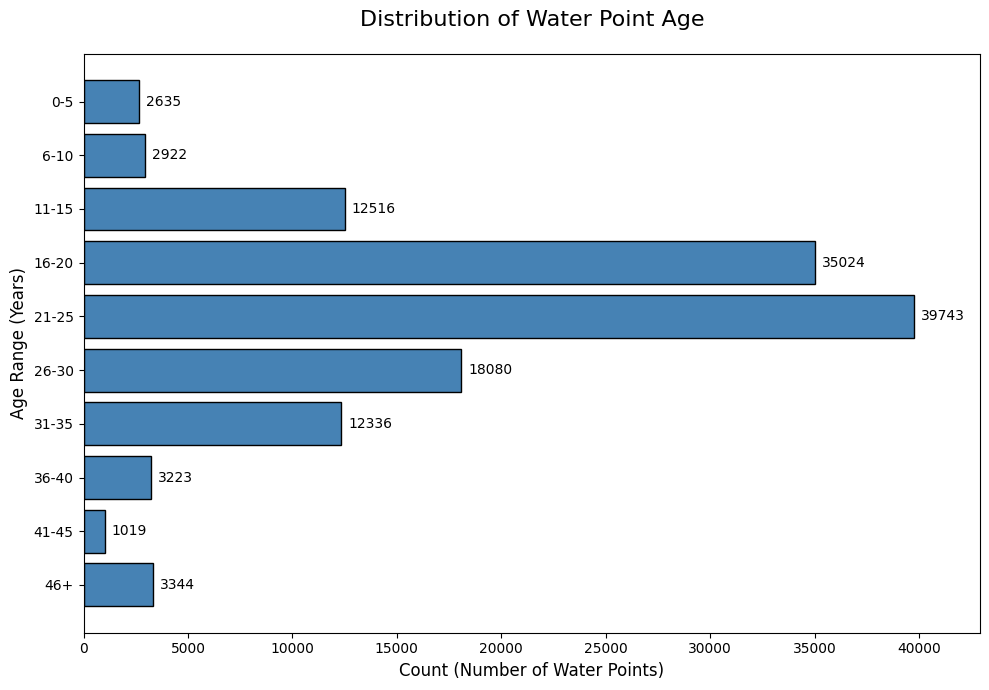

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define bin edges and labels
edges = [-1,5,10,15,20,25,30,35,40,45,df["Water_Point_Age"].max()]
labels = [
    "0-5","6-10","11-15","16-20","21-25",
    "26-30","31-35","36-40","41-45","46+"
]

# 2. Categorize data
df['Age_Group'] = pd.cut(df["Water_Point_Age"], bins=edges, labels=labels)

# 3. Create summary table
table_df = df['Age_Group'].value_counts().sort_index().reset_index()
table_df.columns = ["Age Range (Years)", "Count"]

# 4. Plot
fig, ax = plt.subplots(figsize=(10,7))
bars = ax.barh(table_df["Age Range (Years)"], table_df["Count"],
               color='steelblue', edgecolor='black')

# Add values
ax.bar_label(bars, padding=5)

# Formatting
ax.set_title("Distribution of Water Point Age", fontsize=16, pad=20)
ax.set_xlabel("Count (Number of Water Points)", fontsize=12)
ax.set_ylabel("Age Range (Years)", fontsize=12)

ax.invert_yaxis()
#ax.grid(axis='x', linestyle='--', alpha=0.7)

# Extend axis so labels stay inside
ax.set_xlim(0, table_df["Count"].max()*1.08)

plt.tight_layout()
plt.show()

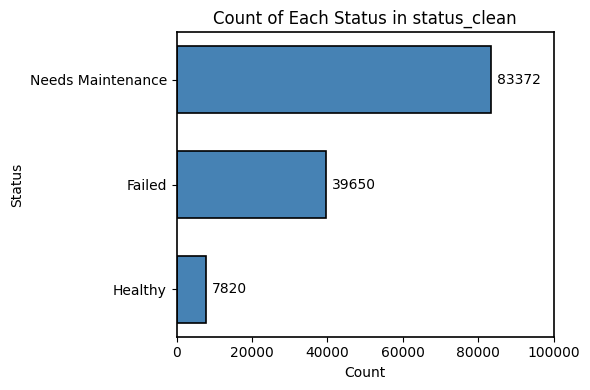

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Count values
status_counts = df['status_clean'].value_counts()

# Create custom y positions (closer spacing)
y_pos = np.arange(len(status_counts)) * 0.7   # spacing factor

fig, ax = plt.subplots(figsize=(6,4))

bars = ax.barh(
    y_pos,
    status_counts.values,
    height=0.45,          # keep same bar thickness
    edgecolor='black',
    linewidth=1.2,
    color='steelblue'
)

# Labels on y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(status_counts.index)

# Largest on top
ax.invert_yaxis()

ax.set_xlabel('Count')
ax.set_ylabel('Status')
ax.set_title('Count of Each Status in status_clean')

# Add values
ax.bar_label(bars, padding=4)

# Extend axis
ax.set_xlim(0, status_counts.max()*1.2)

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.7)

# Black border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

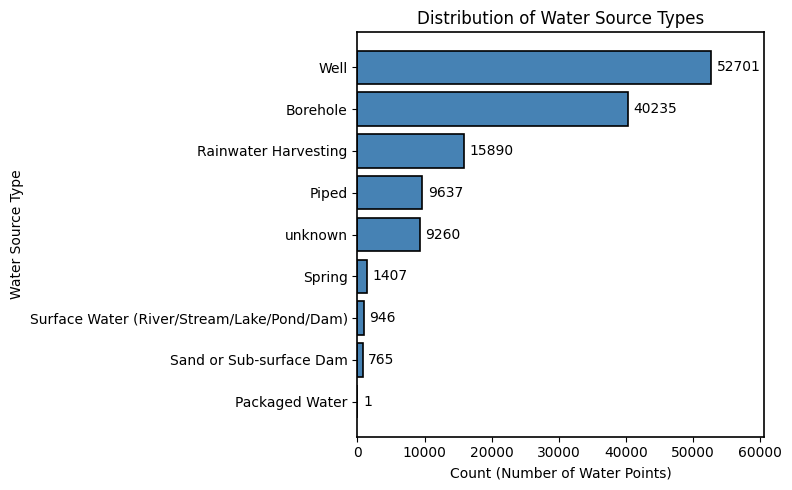

In [ ]:
import matplotlib.pyplot as plt

# Count values
source_counts = df['water_source_clean'].value_counts()

# Create figure
fig, ax = plt.subplots(figsize=(8,5))

bars = ax.barh(
    source_counts.index,
    source_counts.values,
    height=0.8,                # bars close together
    color='steelblue',
    edgecolor='black',
    linewidth=1.2
)

# Largest on top
ax.invert_yaxis()

# Labels
ax.set_xlabel('Count (Number of Water Points)')
ax.set_ylabel('Water Source Type')
ax.set_title('Distribution of Water Source Types')

# Add count labels
ax.bar_label(bars, padding=4)

# Extend axis so numbers stay inside
ax.set_xlim(0, source_counts.max()*1.15)

# Gridlines
#ax.grid(axis='x', linestyle='--', alpha=0.7)

# Black border around plot
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

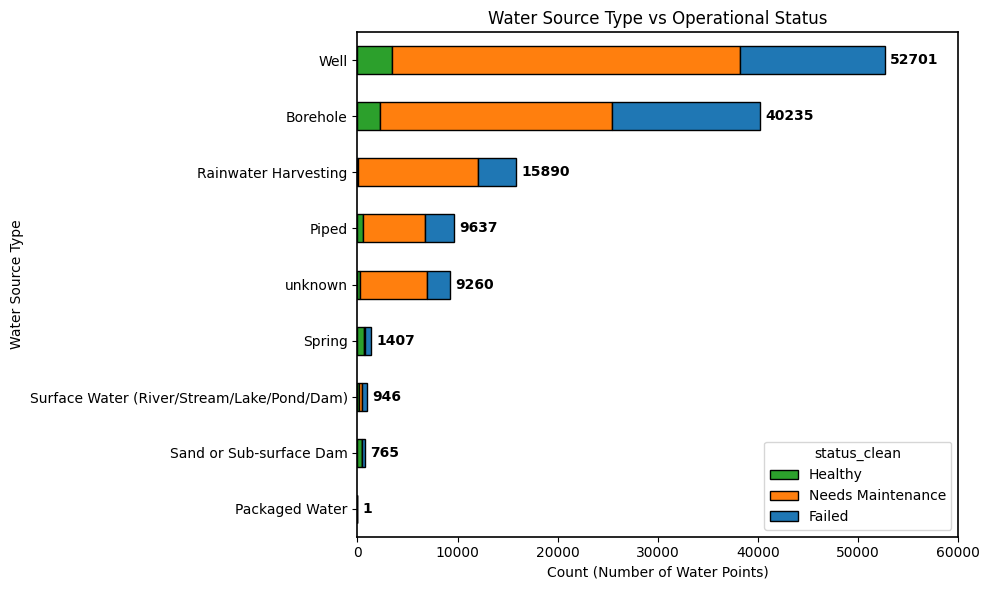

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create grouped table
table = pd.crosstab(df['water_source_clean'], df['status_clean'])

# Reorder columns
table = table[['Healthy', 'Needs Maintenance', 'Failed']]

# Sort rows by total count
table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]

# Plot
fig, ax = plt.subplots(figsize=(10,6))

table.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#2ca02c', '#ff7f0e', '#1f77b4'],  # research-friendly colors
    edgecolor='black'
)

# Labels
ax.set_xlabel('Count (Number of Water Points)')
ax.set_ylabel('Water Source Type')
ax.set_title('Water Source Type vs Operational Status')

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.6)

# Largest on top
ax.invert_yaxis()

# Add total values at end of stacked bars
totals = table.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        total + totals.max()*0.01,
        i,
        f'{total}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Extend axis slightly so numbers stay inside
ax.set_xlim(0, totals.max()*1.139)

# Black border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

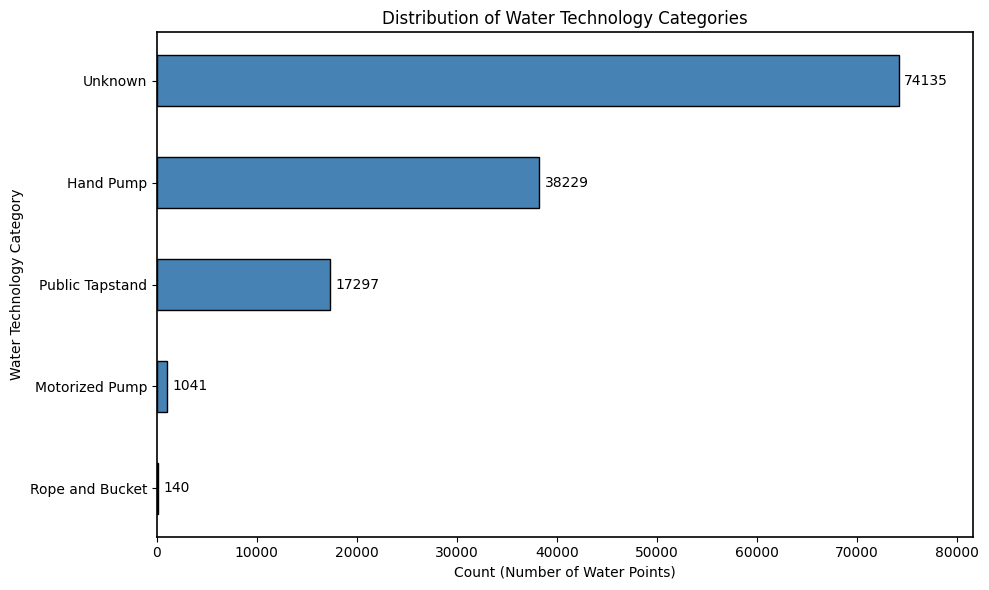

In [ ]:
import matplotlib.pyplot as plt

# Count values
tech_counts = df['water_tech_category'].value_counts()

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    tech_counts.index,
    tech_counts.values,
    color='steelblue',
    edgecolor='black',
    height=0.5
)

# Largest on top
ax.invert_yaxis()

# Labels
ax.set_xlabel('Count (Number of Water Points)')
ax.set_ylabel('Water Technology Category')
ax.set_title('Distribution of Water Technology Categories')

# Add values
ax.bar_label(bars, padding=4)

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.6)

# Extend axis
ax.set_xlim(0, tech_counts.max()*1.1)

# Black border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

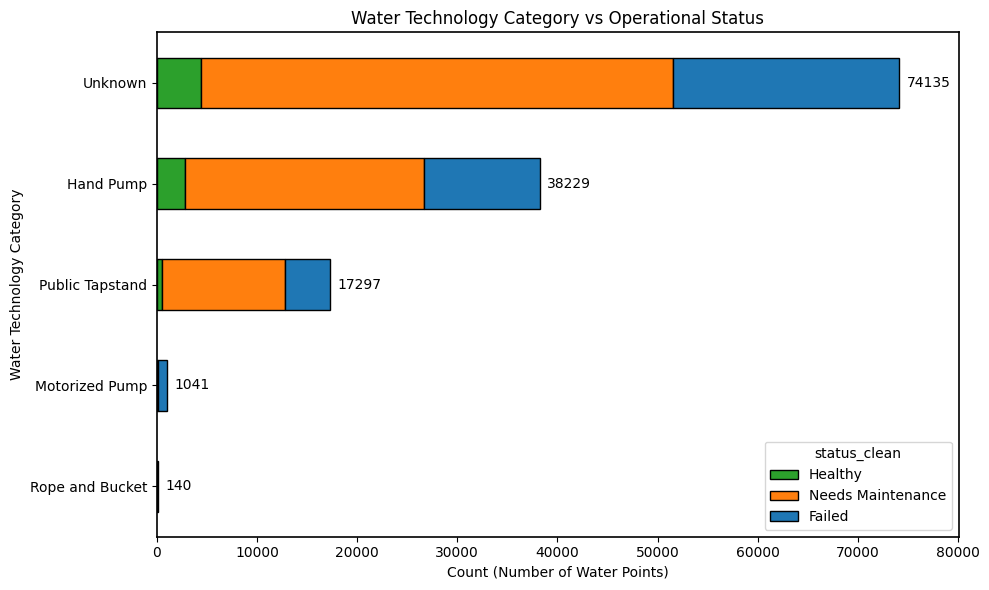

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crosstab
table = pd.crosstab(df['water_tech_category'], df['status_clean'])

# Order columns
table = table[['Healthy', 'Needs Maintenance', 'Failed']]

# Sort by total
table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10,6))

table.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#2ca02c', '#ff7f0e', '#1f77b4'],  # Healthy, Needs Maintenance, Failed
    edgecolor='black'
)

# Labels
ax.set_xlabel('Count (Number of Water Points)')
ax.set_ylabel('Water Technology Category')
ax.set_title('Water Technology Category vs Operational Status')

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.6)

# Largest on top
ax.invert_yaxis()

# Add total values
totals = table.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + totals.max()*0.01, i, f'{total}', va='center', fontsize=10)

# Extend axis
ax.set_xlim(0, totals.max()*1.08)

# Border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

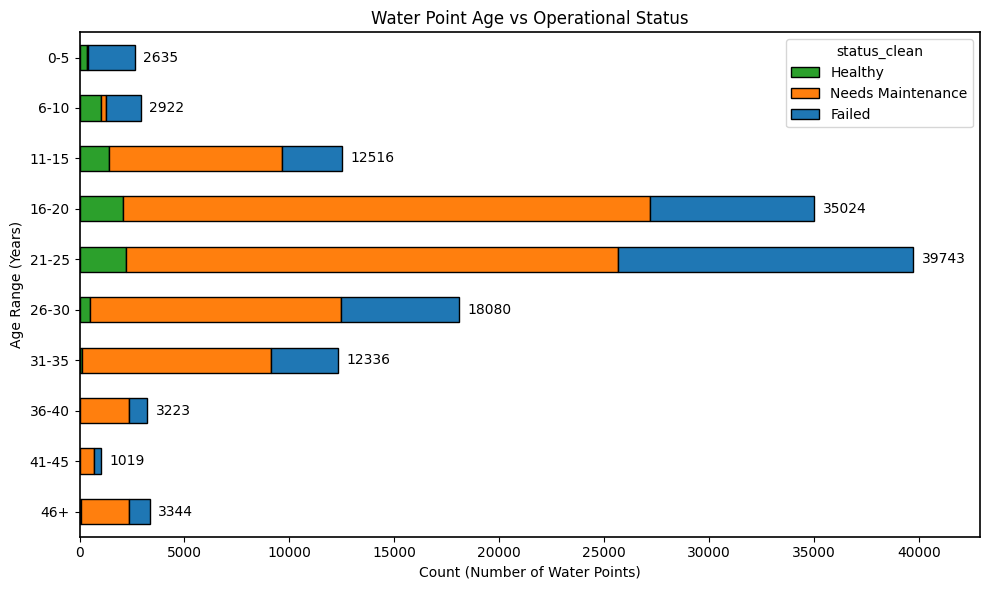

In [ ]:
# Create cross table
table = pd.crosstab(df['Age_Group'], df['status_clean'])

# Order columns
table = table[['Healthy', 'Needs Maintenance', 'Failed']]

# Plot
fig, ax = plt.subplots(figsize=(10,6))

table.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#2ca02c', '#ff7f0e', '#1f77b4'],
    edgecolor='black'
)

ax.set_xlabel('Count (Number of Water Points)')
ax.set_ylabel('Age Range (Years)')
ax.set_title('Water Point Age vs Operational Status')

#ax.grid(axis='x', linestyle='--', alpha=0.6)

ax.invert_yaxis()

# Add totals
totals = table.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + totals.max()*0.01, i, f'{total}', va='center', fontsize=10)

ax.set_xlim(0, totals.max()*1.08)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

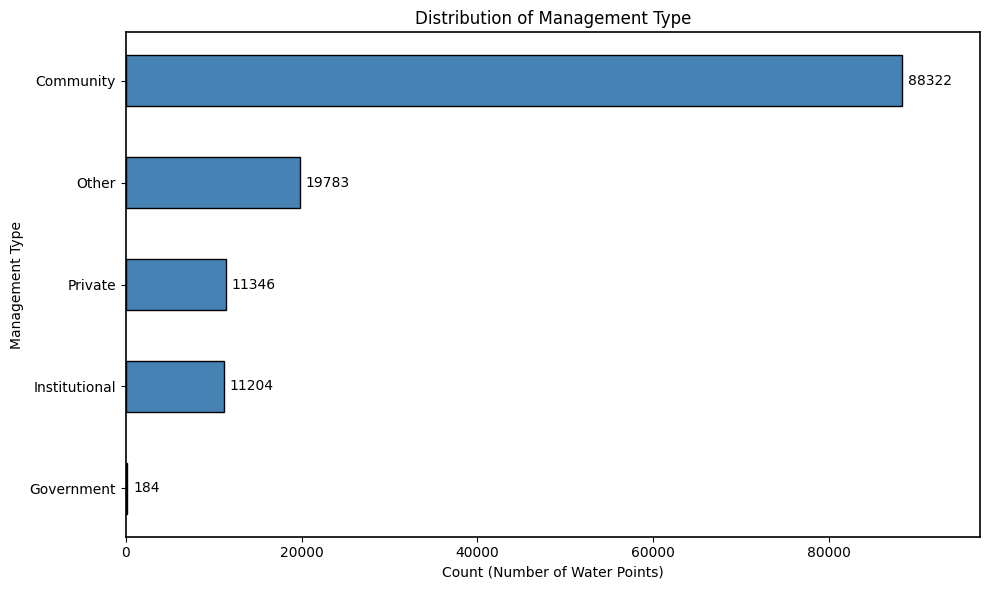

In [ ]:
import matplotlib.pyplot as plt

# Count management types
mgmt_counts = df['management_clean'].value_counts()

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    mgmt_counts.index,
    mgmt_counts.values,
    color='steelblue',
    edgecolor='black',
    height=0.5
)

# Largest on top
ax.invert_yaxis()

# Labels
ax.set_xlabel('Count (Number of Water Points)')
ax.set_ylabel('Management Type')
ax.set_title('Distribution of Management Type')

# Add values
ax.bar_label(bars, padding=4)

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.6)

# Extend axis
ax.set_xlim(0, mgmt_counts.max()*1.1)

# Black border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

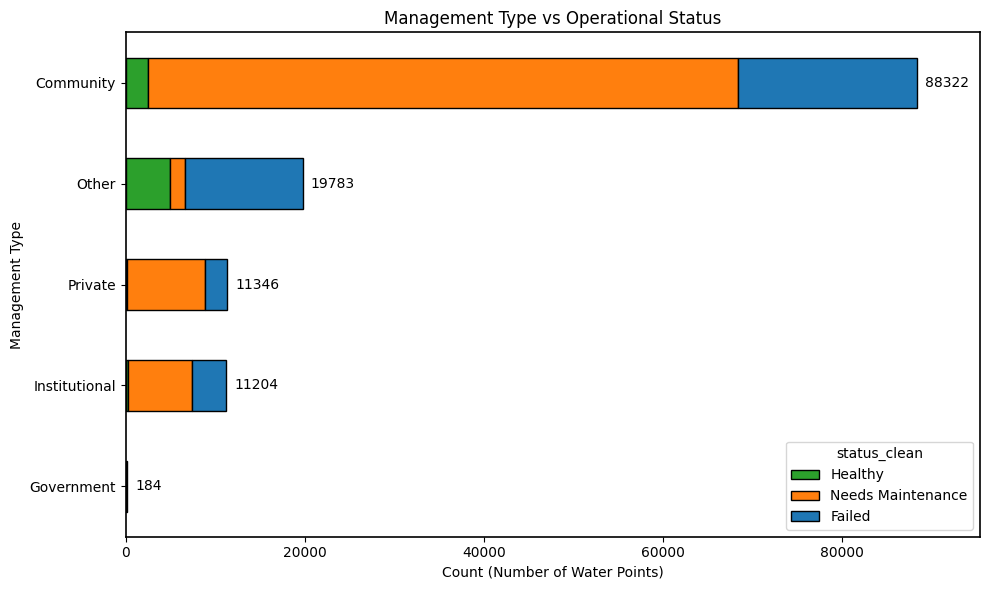

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create crosstab
table = pd.crosstab(df['management_clean'], df['status_clean'])

# Reorder status columns
table = table[['Healthy', 'Needs Maintenance', 'Failed']]

# Sort by total count
table = table.loc[table.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10,6))

table.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#2ca02c', '#ff7f0e', '#1f77b4'],
    edgecolor='black'
)

# Labels
ax.set_xlabel('Count (Number of Water Points)')
ax.set_ylabel('Management Type')
ax.set_title('Management Type vs Operational Status')

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.6)

# Largest on top
ax.invert_yaxis()

# Add totals
totals = table.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(total + totals.max()*0.01, i, f'{total}', va='center', fontsize=10)

# Extend axis
ax.set_xlim(0, totals.max()*1.08)

# Border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

In [ ]:
df.head()

,row_id,lat_deg,lon_deg,status_id,water_source_clean,water_tech_category,clean_adm1,clean_adm2,install_year,Water_Point_Age,...,pay_clean,status_clean,subjective_quality_clean,facility_type,count,report_year,report_month,status_numeric,age_group,Age_Group
0,4,3.017319,30.936143,Yes,Borehole,Hand Pump,Northern,Arua,1998,28,...,Paid,Needs Maintenance,Unknown,Improved,1,2010,4,1,26-30,26-30
1,5,3.033349,30.955287,Yes,Borehole,Hand Pump,Northern,Arua,1996,30,...,Paid,Needs Maintenance,Unknown,Improved,1,2010,4,1,26-30,26-30
2,17,3.022349,30.933175,Yes,Well,Unknown,Northern,Arua,1997,29,...,Unknown,Needs Maintenance,Unknown,Improved,1,2010,4,1,26-30,26-30
3,18,3.017763,30.936709,No,Borehole,Hand Pump,Northern,Arua,1998,28,...,Unknown,Failed,Unknown,Improved,1,2010,4,0,26-30,26-30
4,35,3.017768,30.934865,No,Rainwater Harvesting,Unknown,Northern,Arua,2002,24,...,Unknown,Failed,Unknown,Improved,1,2010,4,0,21-25,21-25


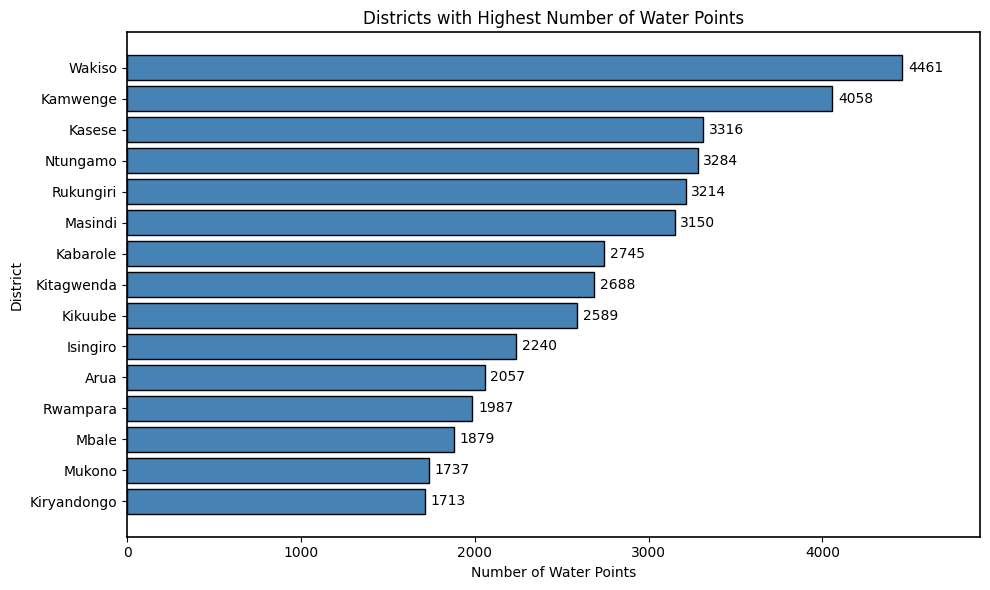

In [ ]:
import matplotlib.pyplot as plt

# Count water points by district
district_counts = df['clean_adm2'].value_counts()

# Select top 10 districts
top_districts = district_counts.head(15)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    top_districts.index,
    top_districts.values,
    color='steelblue',
    edgecolor='black',
    height=0.8
)

# Largest on top
ax.invert_yaxis()

# Labels
ax.set_xlabel('Number of Water Points')
ax.set_ylabel('District')
ax.set_title('Districts with Highest Number of Water Points')

# Add values
ax.bar_label(bars, padding=4)

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.6)

# Extend axis
ax.set_xlim(0, top_districts.max()*1.1)

# Black border
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

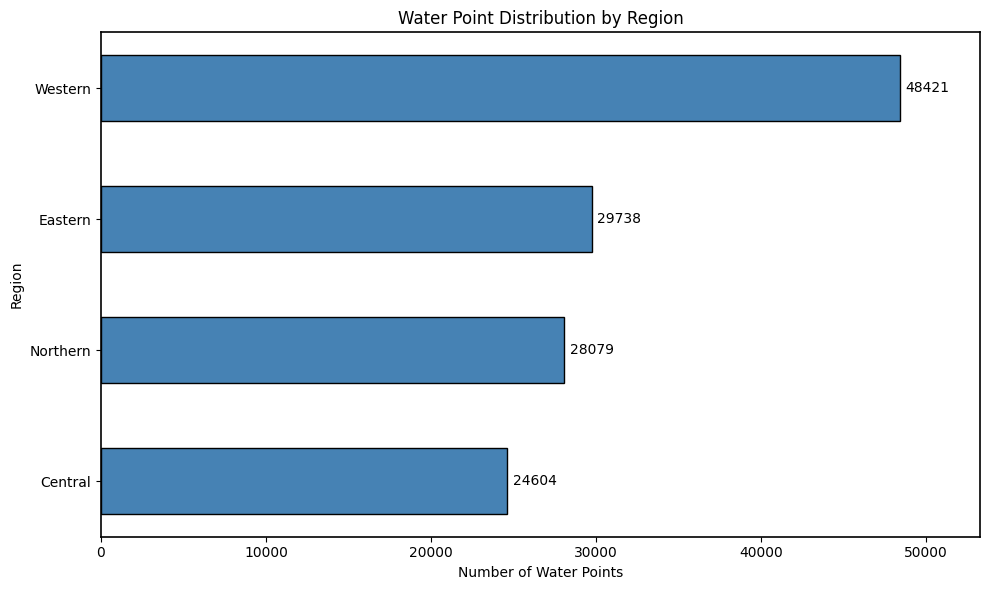

In [ ]:
import matplotlib.pyplot as plt

# Count water points per region
region_counts = df['clean_adm1'].value_counts()

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    region_counts.index,
    region_counts.values,
    color='steelblue',
    edgecolor='black',
    height=0.5
)

# Largest region on top
ax.invert_yaxis()

# Labels
ax.set_xlabel('Number of Water Points')
ax.set_ylabel('Region')
ax.set_title('Water Point Distribution by Region')

# Add values
ax.bar_label(bars, padding=4)

# Grid
#ax.grid(axis='x', linestyle='--', alpha=0.6)

# Extend axis so numbers stay inside
ax.set_xlim(0, region_counts.max()*1.1)

# Black border around graph
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

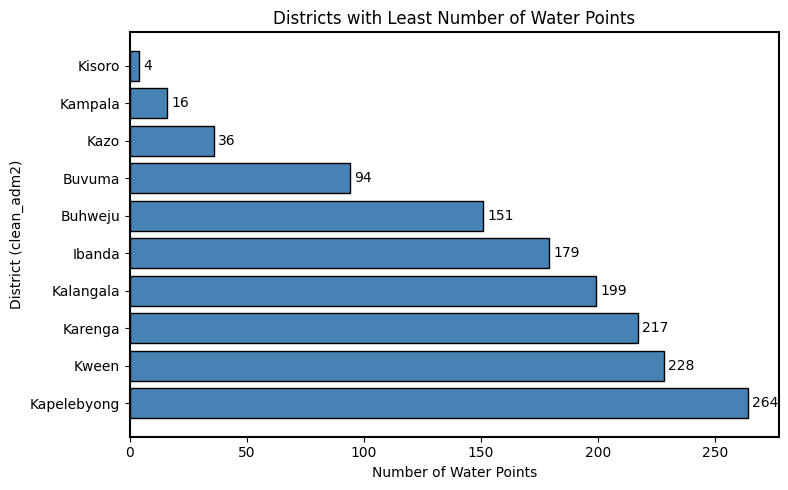

In [ ]:
import matplotlib.pyplot as plt

# Get least 10 districts
least_adm2 = df['clean_adm2'].value_counts().sort_values().head(10)

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.barh(
    least_adm2.index,
    least_adm2.values,
    color='steelblue',
    edgecolor='black',
    height=0.8
)

ax.set_xlabel("Number of Water Points")
ax.set_ylabel("District (clean_adm2)")
ax.set_title("Districts with Least Number of Water Points")

ax.bar_label(bars, padding=3)

#ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()